In [1]:
from __future__ import annotations
import numpy as np
from pathlib import Path

from chirpy.geometry import ImageGrid2D, TransducerArray2D, GeometryConfigurator
from chirpy.optimization.operator import WaveOperator
from chirpy.optimization.operator.helmholtz import HelmholtzOperator
from chirpy.signals import GaussianModulatedPulse
from chirpy.utils.progress import Progress, ProgressConfig
from chirpy.utils.dtft_wavefield import dtft_wavefield

import matplotlib.pyplot as plt  # <-- new


def compute_pulse_spectrum(pulse_t: np.ndarray, dt: float, freq: float) -> complex:
    """
    Compute continuous-FT style spectrum of a real pulse sampled on uniform grid.

    pulse_t : (nt,) time samples
    dt      : time step
    freq    : frequency in Hz

    Uses convention: W(f) = ∫ w(t) e^{-i 2π f t} dt ≈ Σ w[n] e^{-i 2π f n dt} dt
    """
    nt = pulse_t.size
    t = np.arange(nt, dtype=float) * dt
    kernel = np.exp(-1j * 2.0 * np.pi * freq * t)
    W = np.sum(pulse_t * kernel) * dt
    return W



# ---------------- Basic configuration ----------------
C0 = 1500.0          # homogeneous medium (m/s)
F0 = 0.3e6           # central frequency of the pulse & test frequency (Hz)
NX = NY = 240
DX = DY = 1e-3       # 1 mm spacing
N_TX = 32
RADIUS_M = 110e-3     # 110 mm ring radius

use_gpu_td = False   # WaveOperator: k-Wave CPU or GPU
use_gpu_fd = False   # HelmholtzOperator: GPU block-LU or CPU splu

KWAVE_BIN = None

progress = Progress(ProgressConfig(enabled=True, backend="tqdm", ncols=90))

# ---------------- Grid & ring array ----------------
grid = ImageGrid2D(nx=NX, dx=DX)  # square grid
tx_array = TransducerArray2D.from_ring_array_2D(r=RADIUS_M, grid=grid, n=N_TX)
geom_config = GeometryConfigurator(grid, tx_array)
geom_config.configure_acceptance(delta=0)
# 只保留一个 Tx（每 32 个取一个）
geom_config.select_tx(step=32)

# ---------------- Time-domain operator ----------------
medium_td = {
    "sound_speed": np.full((grid.ny, grid.nx), C0, dtype=np.float32),
    "density": np.full((grid.ny, grid.nx), 1000.0, dtype=np.float32),
    "alpha_coeff": np.zeros((grid.ny, grid.nx), dtype=np.float32),
    "alpha_power": 1.01,
    "alpha_mode": "no_dispersion",
}

width = grid.extent[1] - grid.extent[0]
record_time = 1.3 * width / C0  # 和 wave_gen 里类似

pulse = GaussianModulatedPulse(f0=F0, frac_bw=0.75, amp=1.0)

op_td = WaveOperator(
    geom_config=geom_config,
    medium_params=medium_td,
    record_time=record_time,
    tau_max=0.0,
    use_encoding=False,
    drop_self_rx=False,
    record_full_wf=True,
    cfl=0.3,
    c_ref=C0,
    pml_size=10,
    pml_alpha=10.0,
    encoding_seed=None,
    pulse=pulse,
    scale_source_terms=True,
    src_mode="additive",
    pml_inside=False,
    use_gpu=use_gpu_td,
    verbose=False,
    progress=progress,
    binary_path=KWAVE_BIN,
)

dt = op_td.dt
time_axis = op_td.time_axis
nt = time_axis.size
print(f"[TD] dt={dt:.3e}s, nt={nt}, T={nt*dt*1e6:.1f} µs")

# 均匀介质速度场
c_hom = np.full((grid.ny, grid.nx), C0, dtype=np.float32)

# forward (time-domain), record full wavefield
_ = op_td.forward(model=c_hom, kind="c")
wf_td = op_td.get_forward_fields()  # (n_tx, nt, ny, nx)
n_tx, _, ny, nx = wf_td.shape
print(f"[TD] wf_td shape = {wf_td.shape} (Tx, T, Ny, Nx)")

# ---------------- DTFT to frequency domain ----------------
freqs = np.array([F0], dtype=float)  # single frequency
wf_fd_from_td = dtft_wavefield(wf_td, dt=dt, freqs=freqs)  # (ny, nx, n_tx, 1)
wf_fd_from_td = wf_fd_from_td[..., 0]  # (ny, nx, n_tx)
print(f"[TD→FD] wf_fd_from_td shape = {wf_fd_from_td.shape} (Ny, Nx, Tx)")

# ---------------- Frequency-domain Helmholtz operator ----------------
slow_hom = np.full((grid.ny, grid.nx), 1.0 / C0, dtype=np.complex128)

op_fd = HelmholtzOperator(
    data=None,
    geom_config=geom_config,
    f_idx=None,
    freq=F0,
    sign_conv=-1,
    pml_alpha=10.0,
    pml_size=10*DX,
    use_gpu=use_gpu_fd,
    progress=progress,
)

_ = op_fd.forward(slow_hom)  # (Tx, Rx)
WF_fd = op_fd.get_field("WF")          # (ny, nx, n_tx)
print(f"[FD] WF_fd shape = {WF_fd.shape} (Ny, Nx, Tx)")

# ---------------- Align shapes & basic sanity ----------------
assert WF_fd.shape == wf_fd_from_td.shape, "Shape mismatch between TD-FT and FD WF"

# ---------------- Compute pulse spectrum (continuous FT style) ----------------
pulse_t = op_td.pulse[0]  # (nt,)
W_f0 = compute_pulse_spectrum(pulse_t, dt, F0)
print(f"[Pulse] |W(f0)| = {abs(W_f0):.3e}")

# ---------------- Various comparisons ----------------
eps = 1e-12

[WaveOperator] Init → Tx=1, Rx=32, nt=1036, dt=2.000e-07s, grid=(240×240,1.00e-03×1.00e-03m), c_ref=1500.0m/s, cfl=0.3, pml=10, enc=False, tau_max=0.000e+00s, dsrx=False, full_wf=True, src_mode=additive, rx_order=element, pulse={'Type': 'GaussianModulatedPulse', 'attrs': {'f0': 300000.0, 'frac_bw': 0.75, 'amp': 1.0, 'bwr': -6.0, 'tpr': -80.0}}
[TD] dt=2.000e-07s, nt=1036, T=207.2 µs
[TDO-FWD] Done | shots=1, total=3.68s, mean/shot=3.68s
[TD] wf_td shape = (1, 1036, 240, 240) (Tx, T, Ny, Nx)
[TD→FD] wf_fd_from_td shape = (240, 240, 1) (Ny, Nx, Tx)
[FD] WF_fd shape = (240, 240, 1) (Ny, Nx, Tx)
[Pulse] |W(f0)| = 2.084e-06


In [2]:
wf_fd_from_td.shape

(240, 240, 1)

In [18]:
ratio_raw = WF_fd / (wf_fd_from_td * 0.2 + eps)
amp_ratio_raw = np.abs(ratio_raw)
phase_diff_raw = np.angle(ratio_raw)   # rad

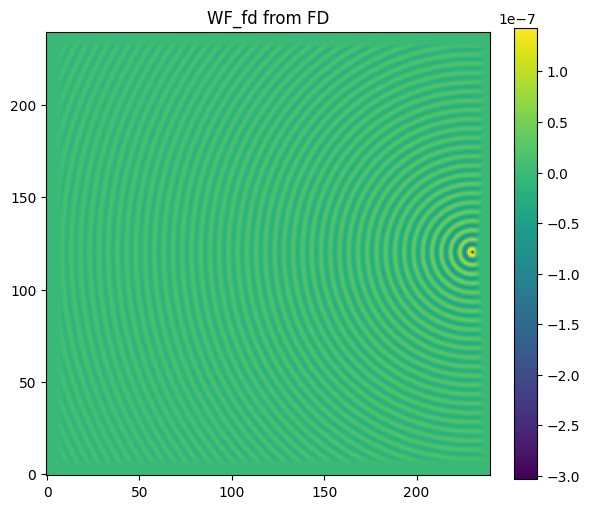

<Axes: title={'center': 'WF_fd from FD'}>

In [19]:
from chirpy.data import ImageData
ImageData(WF_fd[:,:,0]).show(cmap="viridis", title="WF_fd from FD")

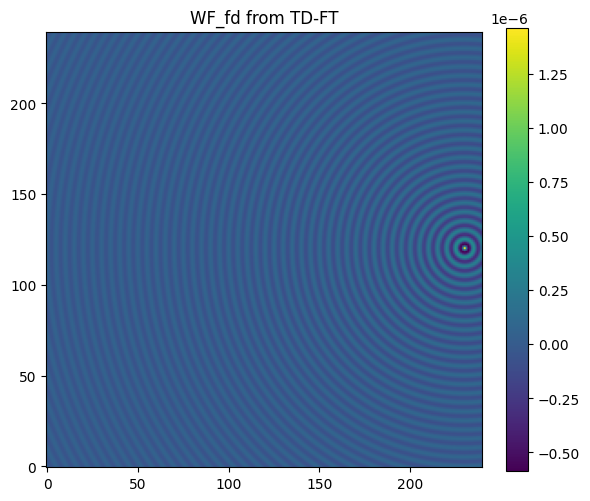

<Axes: title={'center': 'WF_fd from TD-FT'}>

In [20]:
ImageData(wf_fd_from_td[:,:,0]).show(cmap="viridis", title="WF_fd from TD-FT")

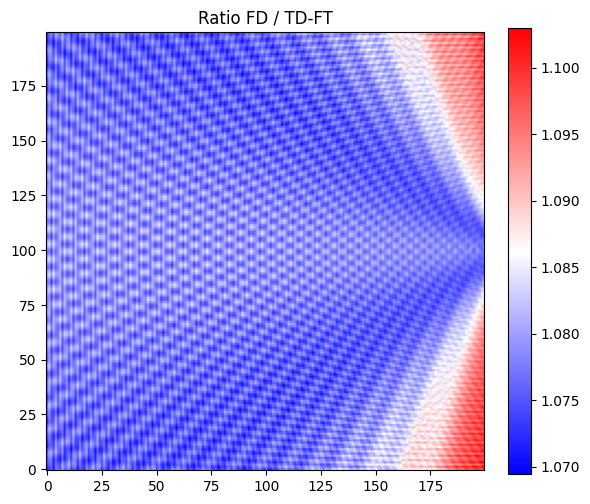

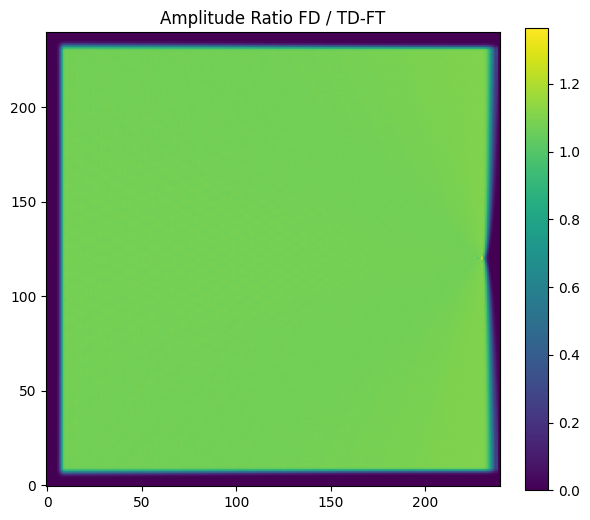

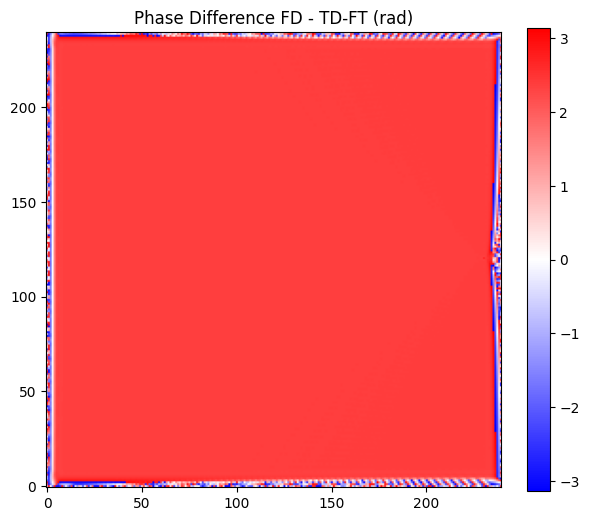

<Axes: title={'center': 'Phase Difference FD - TD-FT (rad)'}>

In [21]:
ImageData(ratio_raw[:,:,0][20:-20,20:-20]).show(cmap="bwr", title="Ratio FD / TD-FT")
ImageData(amp_ratio_raw[:,:,0]).show(cmap="viridis", title="Amplitude Ratio FD / TD-FT")
ImageData(phase_diff_raw[:,:,0]).show(cmap="bwr", title="Phase Difference FD - TD-FT (rad)")

In [23]:
rel_l2 = np.linalg.norm(WF_fd - wf_fd_from_td * 0.2) / np.linalg.norm(WF_fd)
rel_l2

1.826296399245095

In [79]:
W_f0

(5.583461440032614-8.798127415348853j)

In [80]:
G_td = wf_fd_from_td / (W_f0 + eps)
ratio_G = WF_fd / (G_td + eps)
amp_ratio_G = np.abs(ratio_G)
phase_diff_G = np.angle(ratio_G)

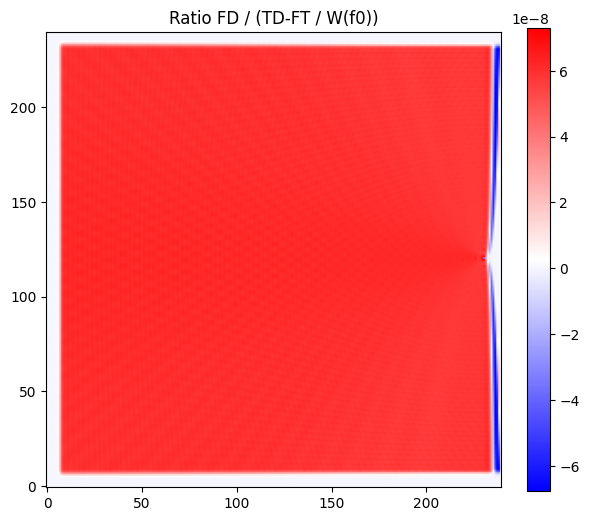

<Axes: title={'center': 'Ratio FD / (TD-FT / W(f0))'}>

In [81]:
ImageData(ratio_G[:,:,0]).show(cmap="bwr", title="Ratio FD / (TD-FT / W(f0))")